# Imports

Enable operations to use the cpu if no Apple gpu implementation is available

In [25]:
from sympy.stats.sampling.sample_numpy import numpy
%env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


Reload modules automagically if they change

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import json
import sklearn
import ot
import torch
from ot_utils import *
from sklearn.svm import SVC
from Utils.SVM_utils import test_svm, train_svm
from einops import rearrange
from Utils.visualization_utils import visualize_barycenter_diracs, plot_images, plot_pca_for_arrays
from Utils.joint_OT_mapping_linear_classreg import free_support_sinkhorn_barycenter, compute_joint_OT_mapping
from warnings import catch_warnings
from map_hyperparam import optimize_hyperparams

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

# Data

In [29]:
data_path = '/Users/balazsmorvay/PycharmProjects/fmri_classifier/Data/Office-Caltech'

Read the image features

In [30]:
dataset = np.load(os.path.join(data_path, 'Objects_Decaf.npy'))
with open(os.path.join(data_path, 'Objects_crossval_index.json'), 'r') as f:
    fold_dict = json.loads(f.read())

domain_names = ['Webcam', 'Amazon', 'dslr', 'Caltech']

Set the number of classes within each domain

In [31]:
n_classes = 10
standardize = True

In [32]:
dataset.shape

(2533, 4098)

In [33]:
X = dataset[:, :-2]
if standardize:
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
else:
    # Feature scaling
    X = (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))

y = np.array(dataset[:, -2], dtype=int)
m = np.array(dataset[:, -1], dtype=int)
domains = np.unique(m).astype(int)
targets = domains
n_domains = len(domains)

Dataset has shape n_points x n_features

In [34]:
X.shape, y.shape, targets.shape

((2533, 4096), (2533,), (4,))

### Number of samples coming from a given domain, having a given class

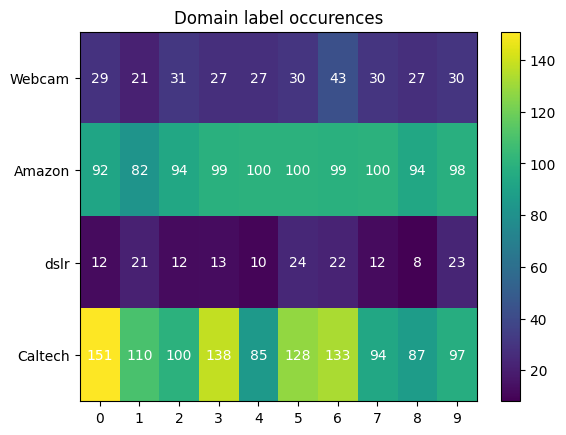

In [35]:
label_domain_occurence = np.zeros((4, 10), dtype=int)
for label in range(10):
    for i, domain in enumerate(domains):
        domain_indices = np.where(m == domain)
        domain_labels = y[domain_indices]
        label_indices = np.where(domain_labels == label+1)
        label_domain_occurence[i][label] = len(label_indices[0])

fig, ax = plt.subplots()
cax = ax.imshow(label_domain_occurence, cmap='viridis', aspect='auto')
for (i, j), val in np.ndenumerate(label_domain_occurence):
    ax.text(j, i, f'{val}', ha='center', va='center', color='white')
fig.colorbar(cax)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(str(i) for i in range(10))
ax.set_yticklabels(domain_names)
plt.title('Domain label occurences')
plt.show()

# Training

In [36]:
X_all = []
y_all = []
for i, domain in enumerate(domains):
    domain_indices = np.where(m == domain)
    X_all.append(torch.tensor(X[domain_indices], dtype=torch.float32, device=device))
    y_all.append(torch.tensor(y[domain_indices], dtype=torch.int, device=device))

In [37]:
X_trains = []
X_tests = []
y_trains = []
y_tests = []

for i in range(len(X_all)):
    X_i = X_all[i].cpu()
    y_i = y_all[i].cpu()
    X_i_train, X_i_test, y_i_train, y_i_test = sklearn.model_selection.train_test_split(X_i, y_i, train_size=0.3, shuffle=True, stratify=y_i, random_state=42)
    X_trains.append(X_i_train.to(device))
    X_tests.append(X_i_test.to(device))
    y_trains.append(y_i_train.to(device))
    y_tests.append(y_i_test.to(device))

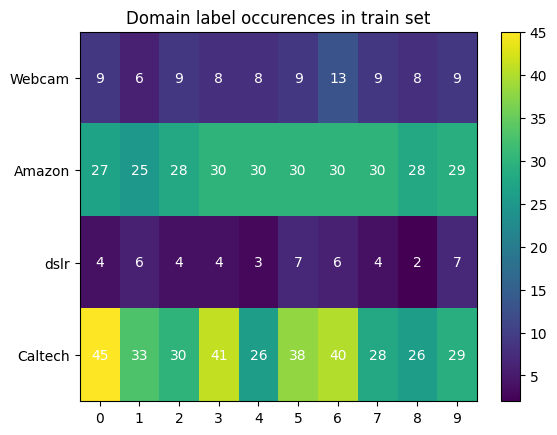

In [38]:
label_domain_occurence = np.zeros((4, 10), dtype=int)
for label in range(10):
    for i in range(n_domains):
        domain_labels = y_trains[i]
        label_indices = np.where(domain_labels.cpu() == label+1)
        label_domain_occurence[i][label] = len(label_indices[0])

fig, ax = plt.subplots()
cax = ax.imshow(label_domain_occurence, cmap='viridis', aspect='auto')
for (i, j), val in np.ndenumerate(label_domain_occurence):
    ax.text(j, i, f'{val}', ha='center', va='center', color='white')
fig.colorbar(cax)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(str(i) for i in range(10))
ax.set_yticklabels(domain_names)
plt.title('Domain label occurences in train set')
plt.show()

Concatenate the train samples into one tensor

In [39]:
Xs = torch.concatenate(tensors=X_trains, dim=0)
ys = torch.concatenate(y_trains, dim=0)
Xs.shape, ys.shape

(torch.Size([758, 4096]), torch.Size([758]))

In [40]:
n_features = 4096

In [41]:
model = train_svm(X_trains[0].cpu(), y_trains[0].cpu(), kernel='rbf', C=1.0)
model.fit_status_ == 0

[LibSVM].*.*
optimization finished, #iter = 31
obj = -4.743459, rho = 0.194978
nSV = 15, nBSV = 0
.*
optimization finished, #iter = 35
obj = -5.609956, rho = 0.145199
nSV = 18, nBSV = 1
.*.*
optimization finished, #iter = 35
obj = -6.090518, rho = 0.401297
nSV = 17, nBSV = 1
.*.*
optimization finished, #iter = 38
obj = -4.402343, rho = 0.384378
nSV = 17, nBSV = 0
.*.*
optimization finished, #iter = 37
obj = -5.571213, rho = 0.343603
nSV = 18, nBSV = 0
.*
optimization finished, #iter = 40
obj = -6.889827, rho = 0.372778
nSV = 22, nBSV = 5
.*
optimization finished, #iter = 29
obj = -6.557554, rho = 0.238393
nSV = 18, nBSV = 5
.*.*
optimization finished, #iter = 36
obj = -4.187777, rho = 0.328174
nSV = 17, nBSV = 0
.*
optimization finished, #iter = 28
obj = -6.734039, rho = 0.309930
nSV = 18, nBSV = 4
.*.*
optimization finished, #iter = 31
obj = -4.704163, rho = -0.061754
nSV = 15, nBSV = 0
.*.*
optimization finished, #iter = 29
obj = -5.388725, rho = 0.177659
nSV = 14, nBSV = 0
.*
optimi

True

{'accuracy': 0.587183308494784, 'recall': array([0.53846154, 0.87719298, 0.65151515, 0.55072464, 0.48571429,
       0.35714286, 0.91304348, 0.54285714, 0.03030303, 0.95652174]), 'precision': array([0.92105263, 1.        , 0.57333333, 0.76      , 0.68      ,
       0.89285714, 0.28636364, 1.        , 1.        , 0.55      ]), 'fscore': array([0.67961165, 0.93457944, 0.60992908, 0.63865546, 0.56666667,
       0.51020408, 0.43598616, 0.7037037 , 0.05882353, 0.6984127 ])}


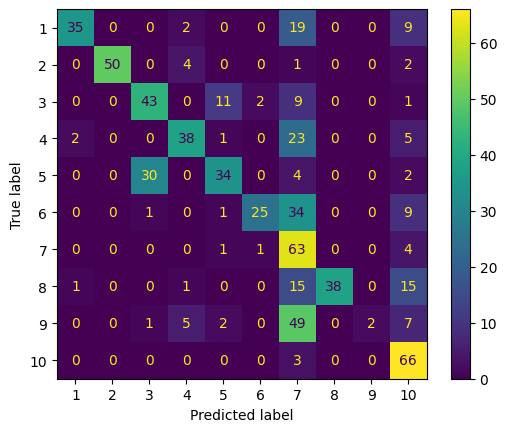

In [42]:
metrics, disp = test_svm(model, X_tests[1].cpu(), y_tests[1].cpu())
disp.plot()
print(metrics)

In [43]:
xs = X_trains[1]
xt = X_trains[0]
ys = y_trains[1]
yt = y_trains[0]
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=2e-1, M=M, method='sinkhorn_log')

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


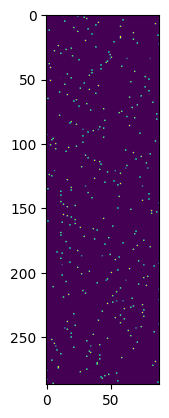

In [44]:
plt.imshow(P.cpu())

In [45]:
transp_xs = barycentric_mapping(xs, xt, X_tests[1], P)

{'accuracy': 0.8628912071535022, 'recall': array([0.93846154, 0.85964912, 0.74242424, 0.69565217, 0.92857143,
       0.92857143, 0.82608696, 0.88571429, 0.93939394, 0.88405797]), 'precision': array([0.96825397, 1.        , 1.        , 0.94117647, 0.66326531,
       0.94202899, 1.        , 0.86111111, 0.68888889, 0.83561644]), 'fscore': array([0.953125  , 0.9245283 , 0.85217391, 0.8       , 0.77380952,
       0.9352518 , 0.9047619 , 0.87323944, 0.79487179, 0.85915493])}


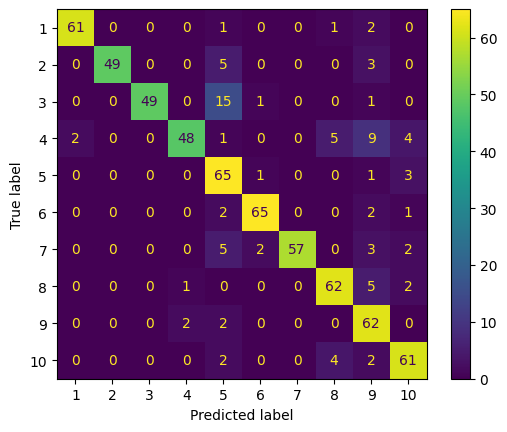

In [46]:
metrics, disp = test_svm(model, transp_xs.cpu(), y_tests[1].cpu())
disp.plot()
print(metrics)

# Using barycenter distributions

Lets first compute the barycenter of the distribution